# 은행 연체율(NPL) 예측 프로젝트 — 탐색적 데이터 분석(EDA)

**주제:** 거시경제 지표로 다음 분기 은행 NPL비율을 예측할 수 있는가?

**데이터:** 2011Q4 ~ 2025Q4 (57개 분기)

**분석 흐름:**
1. 데이터 로드 및 기본 통계
2. NPL비율 시계열 추이
3. 주요 거시경제 지표 시계열
4. 변수 간 상관관계 분석
5. NPL비율과 각 지표의 산점도 + 회귀선
6. 분포 분석
7. 핵심 인사이트 정리

In [1]:
# ──────────────────────────────────────────
# 0. 라이브러리 임포트 및 기본 설정
# ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# ──────────────────────────────────────────
# 1. 데이터 로드 및 기본 정보
# ──────────────────────────────────────────
df = pd.read_csv('../data/processed/dataset.csv')

# quarter 컬럼에서 연도·분기 숫자 추출 (시각화용 x축)
# 예: '2012Q1' → year=2012, quarter_num=1, time_idx=순번 정수
df['year']        = df['quarter'].str[:4].astype(int)
df['quarter_num'] = df['quarter'].str[-1].astype(int)
df['time_idx']    = range(len(df))          # 0, 1, 2, ... (회귀 시 사용)

print('데이터 크기:', df.shape)
print(f"기간: {df['quarter'].iloc[0]} ~ {df['quarter'].iloc[-1]}")
print()
print('=== 기술통계 ===')
df.describe().round(3)

데이터 크기: (57, 13)
기간: 2011Q4 ~ 2025Q4

=== 기술통계 ===


,base_rate,deposit_rate,loan_rate,unemployment_rate,household_loan_balance,BIS비율,NPL비율,ROA,NIM,year,quarter_num,time_idx
count,57.000,57.000,57.000,57.000,57.000,57.000,57.000,57.000,57.000,57.000,57.000,57.000
mean,2.031,2.274,3.912,3.365,1400401.954,15.364,1.040,0.446,1.653,2018.368,2.526,28.000
std,0.949,0.934,0.814,0.611,337210.235,1.125,0.506,0.173,0.189,4.152,1.136,16.598
min,0.500,0.820,2.590,2.170,861387.900,13.830,0.380,0.110,1.410,2011.000,1.000,0.000
25%,1.250,1.520,3.190,2.930,1072020.200,14.260,0.540,0.310,1.540,2015.000,2.000,14.000
50%,1.750,2.000,3.720,3.310,1446376.300,15.380,0.970,0.520,1.610,2018.000,3.000,28.000
75%,2.750,3.030,4.560,3.790,1747665.000,16.490,1.500,0.580,1.670,2022.000,4.000,42.000
max,3.500,4.190,5.700,4.970,1852903.900,17.150,1.870,0.660,2.300,2025.000,4.000,56.000


C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\3146025910.py:30: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages

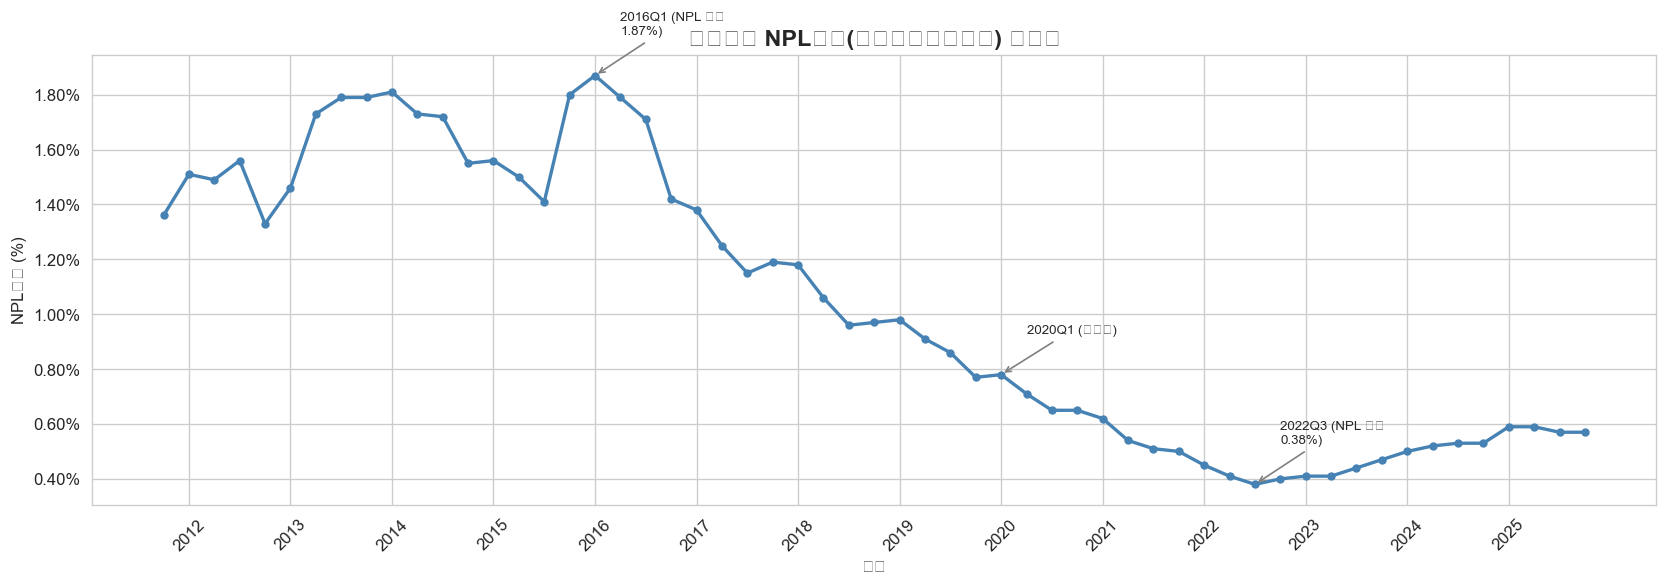

In [3]:
# ──────────────────────────────────────────
# 2. NPL비율 시계열 추이
# ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['time_idx'], df['NPL비율'], color='steelblue', linewidth=2, marker='o', markersize=4)

# x축 눈금: 연도 시작 분기만 표시
year_ticks = df[df['quarter_num'] == 1]['time_idx'].tolist()
year_labels = df[df['quarter_num'] == 1]['year'].tolist()
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45)

# 주요 이벤트 표시
events = {
    '2016Q1 (NPL 최고\n1.87%)': df[df['quarter']=='2016Q1']['time_idx'].values[0],
    '2020Q1 (코로나)':           df[df['quarter']=='2020Q1']['time_idx'].values[0],
    '2022Q3 (NPL 최저\n0.38%)': df[df['quarter']=='2022Q3']['time_idx'].values[0],
}
for label, x in events.items():
    y = df.loc[df['time_idx']==x, 'NPL비율'].values[0]
    ax.annotate(label, xy=(x, y), xytext=(x+1, y+0.15),
                fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'),
                ha='left')

ax.set_title('국내은행 NPL비율(고정이하여신비율) 시계열', fontsize=14, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('NPL비율 (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.savefig('../data/processed/fig_npl_trend.png', bbox_inches='tight')
plt.show()

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:22: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_macro_trends.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:23: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_macro_trends.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:23: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_macro_trends.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:23: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_macro_trends.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\969989196.py:23: UserWarning: Glyp

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages

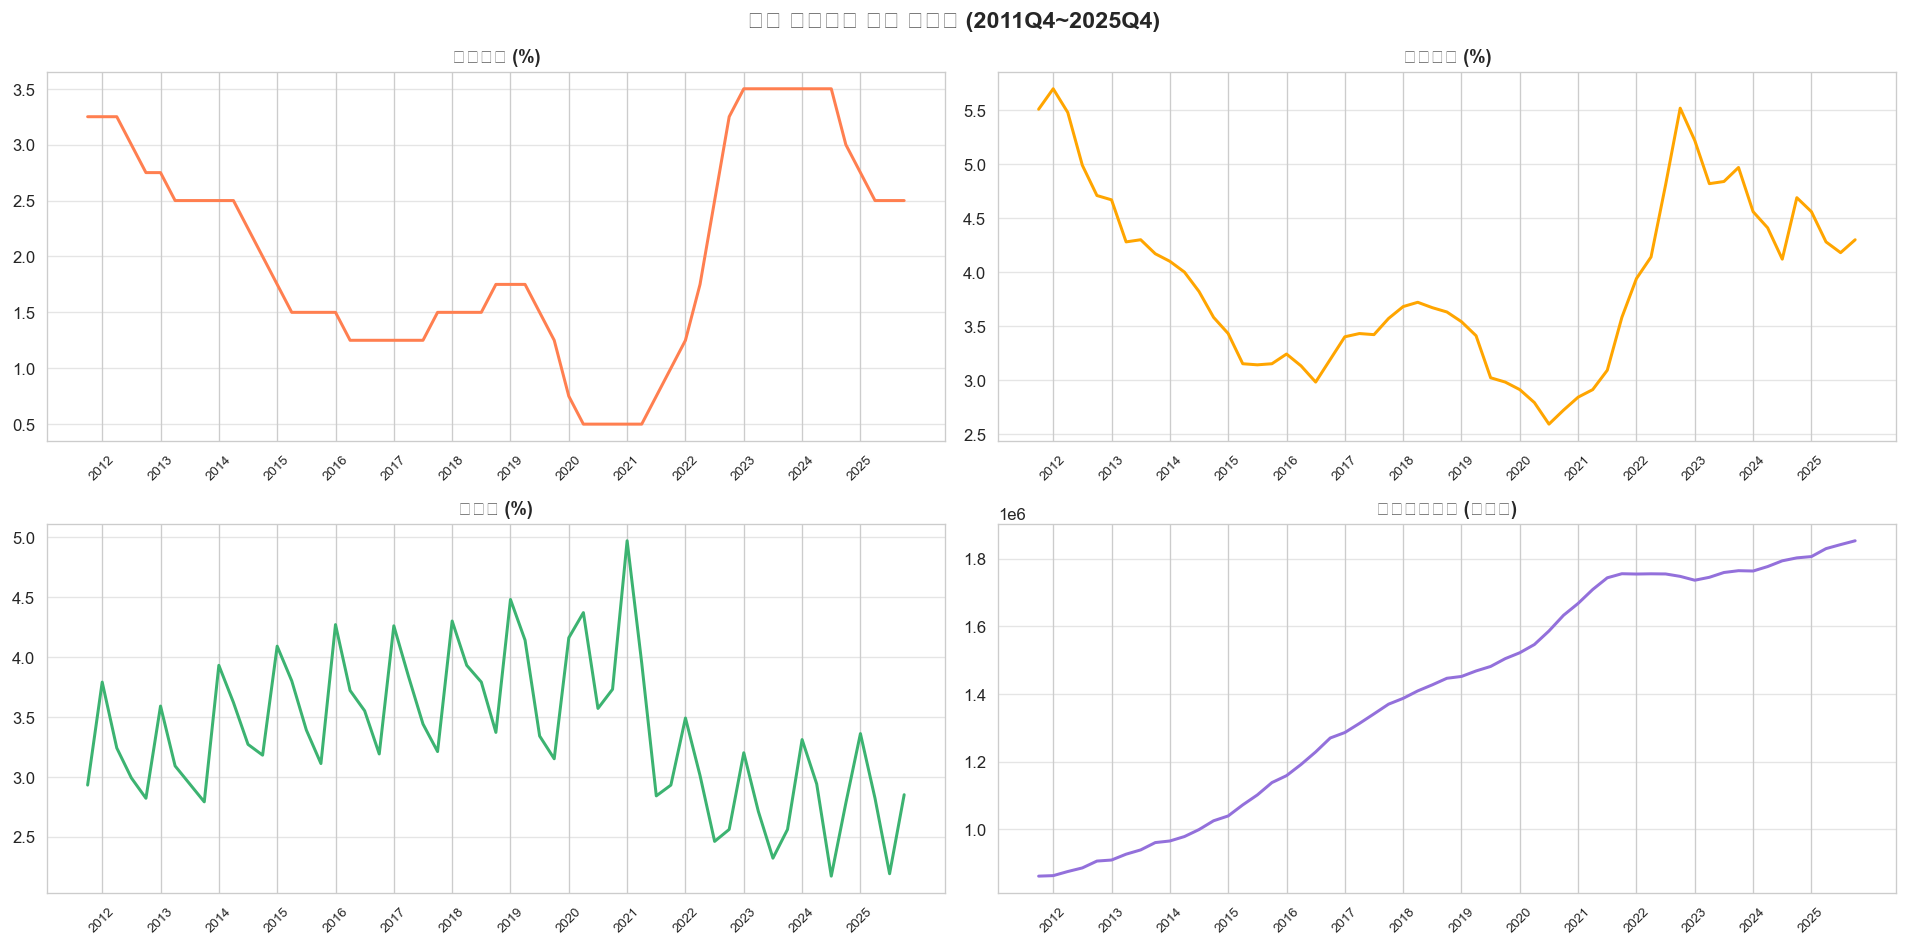

In [4]:
# ──────────────────────────────────────────
# 3. 주요 거시경제 지표 시계열 (4개 패널)
# ──────────────────────────────────────────
indicators = [
    ('base_rate',              '기준금리 (%)',          'coral'),
    ('loan_rate',              '대출금리 (%)',          'orange'),
    ('unemployment_rate',      '실업률 (%)',            'mediumseagreen'),
    ('household_loan_balance', '가계대출잔액 (십억원)', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, indicators):
    ax.plot(df['time_idx'], df[col], color=color, linewidth=1.8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, fontsize=8)
    ax.grid(axis='y', alpha=0.5)

fig.suptitle('주요 거시경제 지표 시계열 (2011Q4~2025Q4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_macro_trends.png', bbox_inches='tight')
plt.show()

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\541355211.py:21: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\541355211.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\541355211.py:21: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\541355211.py:21: UserWarning: Gly

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-package

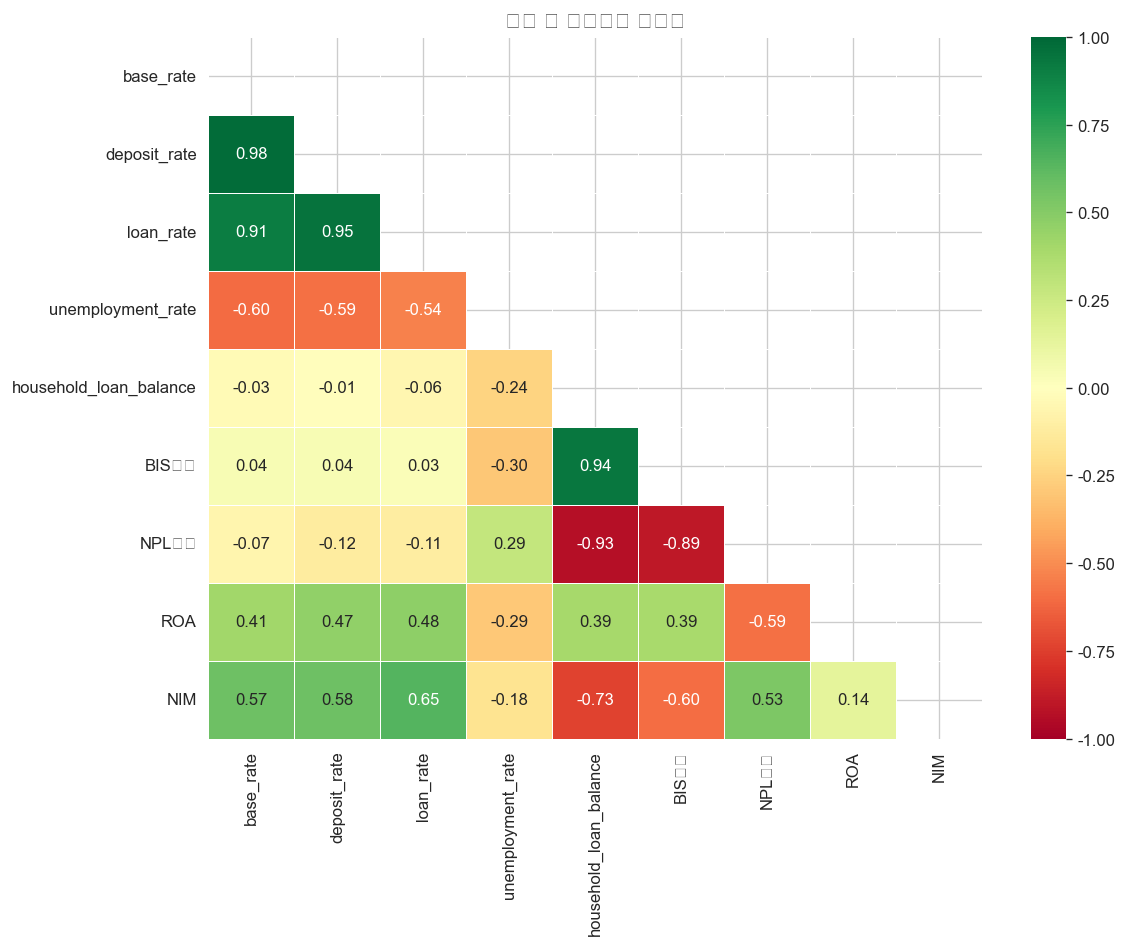


=== NPL비율과의 상관계수 (절댓값 내림차순) ===
  household_loan_balance   : 0.931 (-)
  BIS비율                    : 0.891 (-)
  ROA                      : 0.593 (-)
  NIM                      : 0.531 (+)
  unemployment_rate        : 0.287 (+)
  deposit_rate             : 0.123 (-)
  loan_rate                : 0.110 (-)
  base_rate                : 0.069 (-)


In [5]:
# ──────────────────────────────────────────
# 4. 상관관계 히트맵
# ──────────────────────────────────────────
# 분석에 사용할 수치형 컬럼만 선택
feature_cols = ['base_rate', 'deposit_rate', 'loan_rate',
                'unemployment_rate', 'household_loan_balance',
                'BIS비율', 'NPL비율', 'ROA', 'NIM']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # 중복 삼각형 숨기기
sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('변수 간 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_correlation.png', bbox_inches='tight')
plt.show()

# NPL비율과의 상관계수만 별도 출력 (절댓값 내림차순)
print('\n=== NPL비율과의 상관계수 (절댓값 내림차순) ===')
npl_corr = corr['NPL비율'].drop('NPL비율').abs().sort_values(ascending=False)
for col, val in npl_corr.items():
    sign = corr['NPL비율'][col]
    direction = '(+)' if sign > 0 else '(-)'
    print(f'  {col:25s}: {abs(val):.3f} {direction}')

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:37: UserWarning: Glyph 46993 (\N{HANGUL SYLLABLE RANG}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:38: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:38: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:38: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:38: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\420068750.py:38: UserWarning: Glyph 48708 (\N{HANGUL S

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages

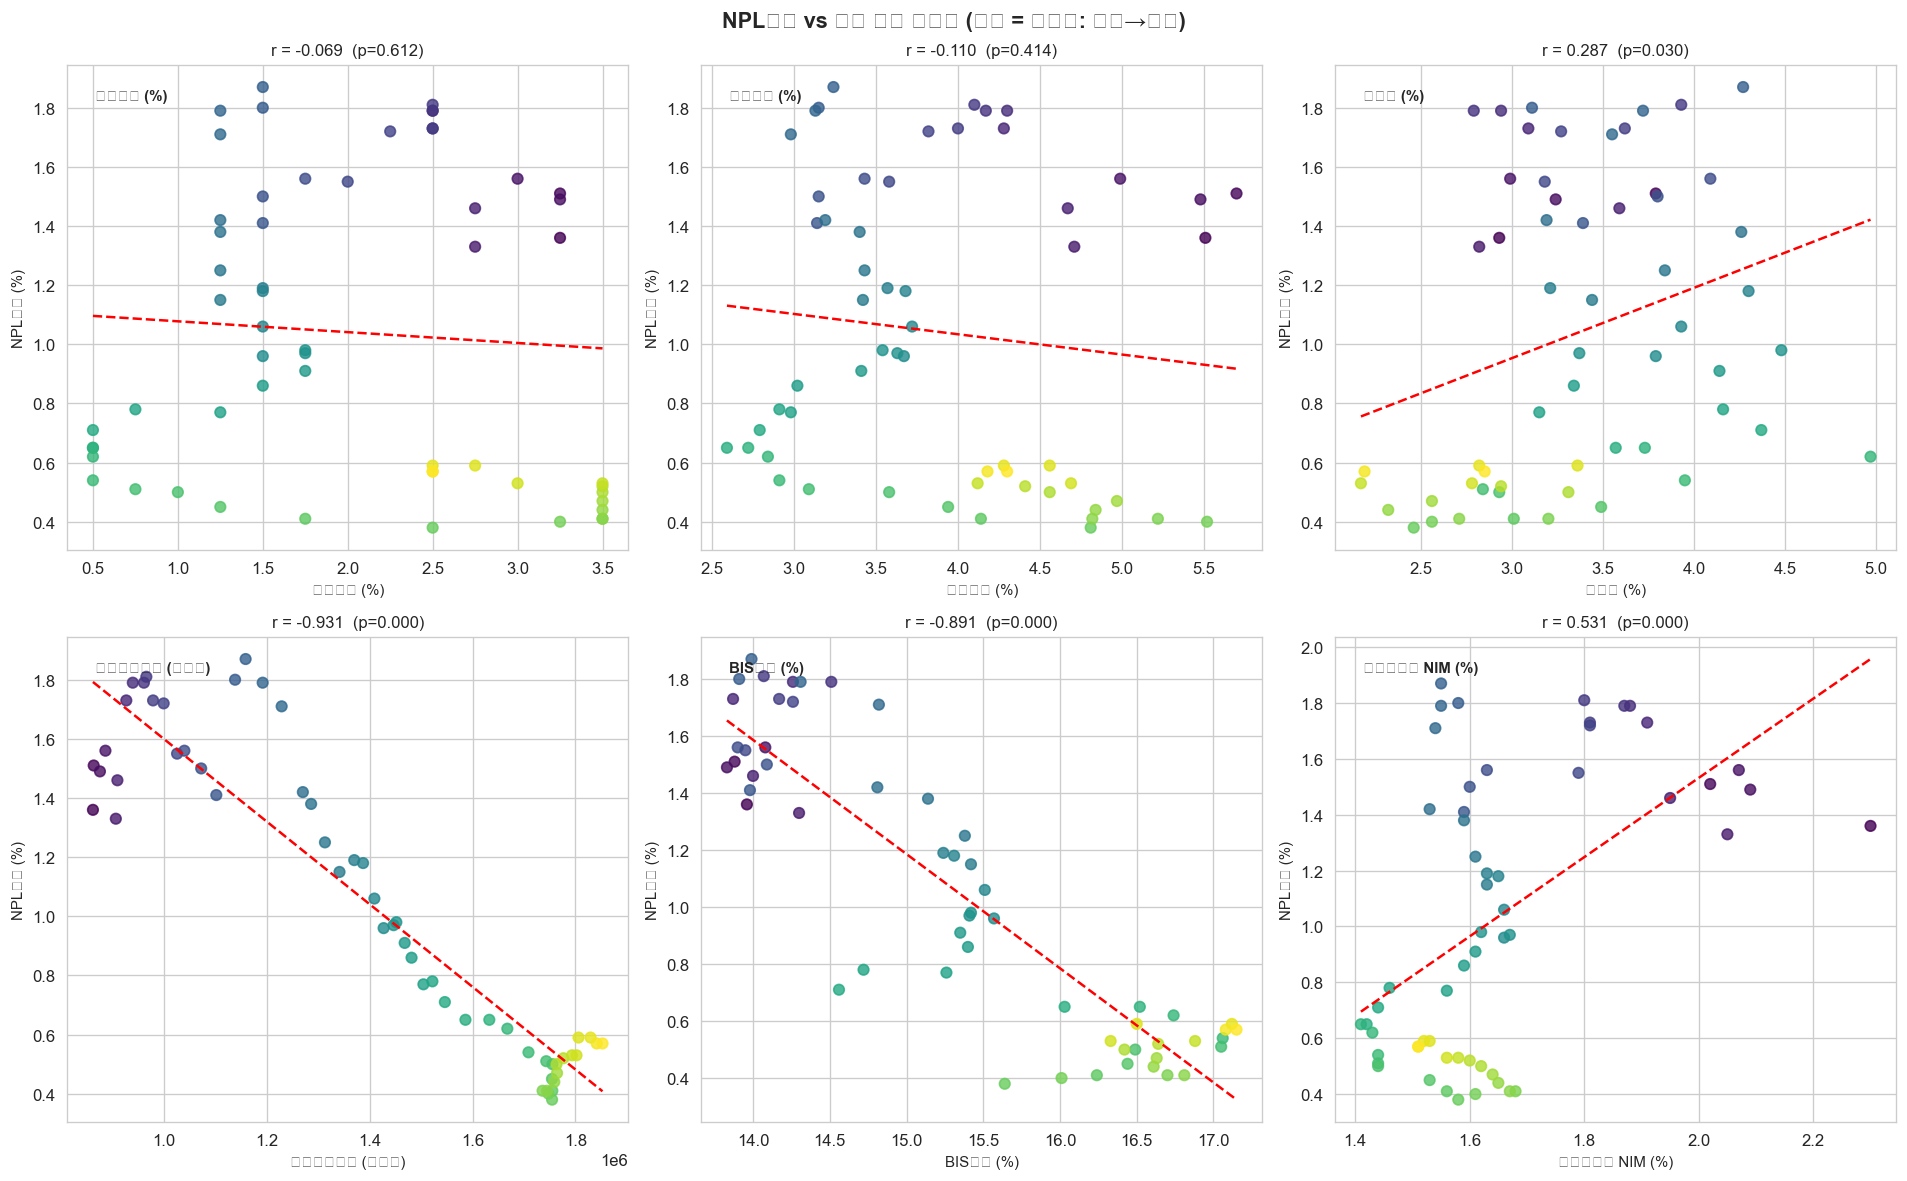

In [6]:
# ──────────────────────────────────────────
# 5. NPL비율 vs 주요 변수 산점도 + 회귀선
# ──────────────────────────────────────────
scatter_vars = [
    ('base_rate',              '기준금리 (%)'),
    ('loan_rate',              '대출금리 (%)'),
    ('unemployment_rate',      '실업률 (%)'),
    ('household_loan_balance', '가계대출잔액 (십억원)'),
    ('BIS비율',                 'BIS비율 (%)'),
    ('NIM',                    '순이자마진 NIM (%)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, scatter_vars):
    x = df[col]
    y = df['NPL비율']
    r, p = stats.pearsonr(x, y)

    # 산점도 (연도별 색상 그라디언트)
    sc = ax.scatter(x, y, c=df['time_idx'], cmap='viridis', s=40, alpha=0.8)

    # 회귀선
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m*x_line + b, 'r--', linewidth=1.5)

    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('NPL비율 (%)', fontsize=9)
    ax.set_title(f'r = {r:.3f}  (p={p:.3f})', fontsize=10)
    ax.text(0.05, 0.95, label, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

fig.suptitle('NPL비율 vs 주요 변수 산점도 (색상 = 시간순: 보라→노랑)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight')
plt.show()

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:16: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:17: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_distribution.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:17: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_distribution.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:17: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_distribution.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:17: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.savefig('../data/processed/fig_distribution.png', bbox_inches='tight')
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\1274419865.py:17: UserWarn

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-pack

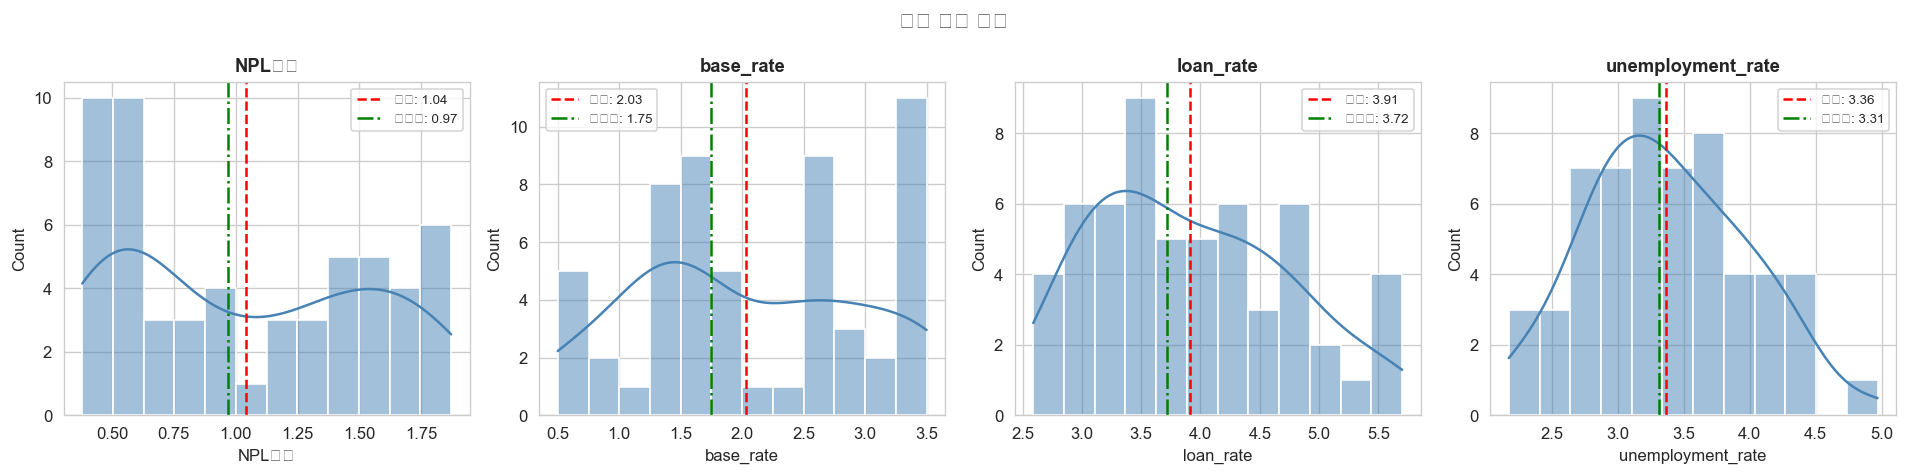

In [7]:
# ──────────────────────────────────────────
# 6. 분포 분석: 히스토그램 + KDE
# ──────────────────────────────────────────
dist_cols = ['NPL비율', 'base_rate', 'loan_rate', 'unemployment_rate']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, dist_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=12)
    ax.axvline(df[col].mean(), color='red',    linestyle='--', label=f'평균: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-.',  label=f'중앙값: {df[col].median():.2f}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('주요 변수 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_distribution.png', bbox_inches='tight')
plt.show()

C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Kim SoonHa\AppData\Local\Temp\ipykernel_22272\2261996952.py:33: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing fro

C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Kim SoonHa\AppData\Local\Programs\Python\Python313\Lib\site-packag

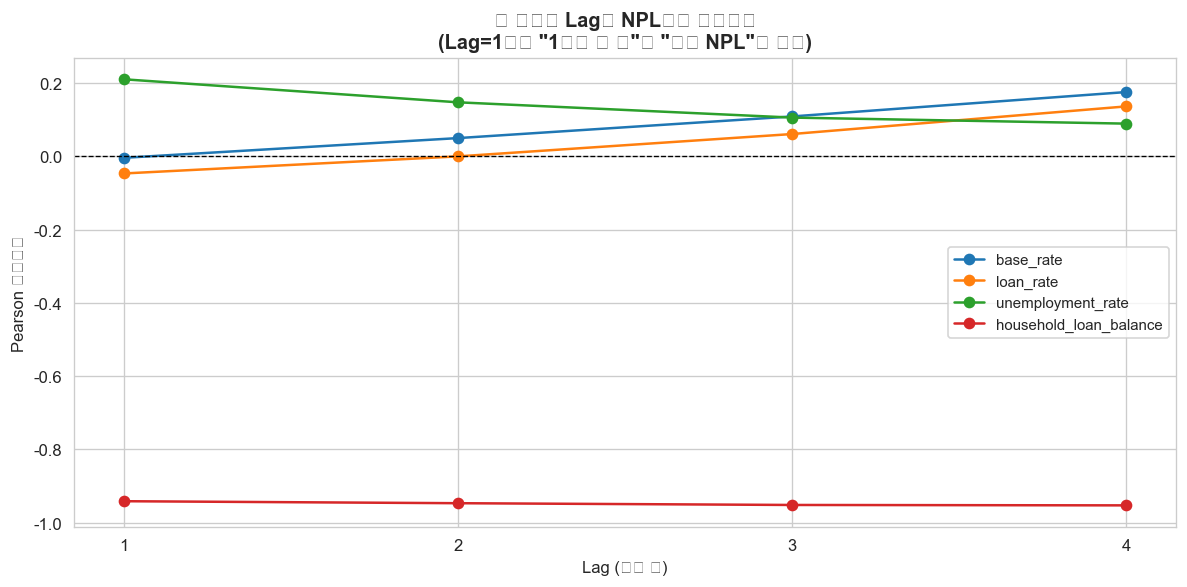

Lag(분기)                     1      2      3      4
변수                                                
base_rate              -0.004  0.050  0.109  0.176
household_loan_balance -0.942 -0.947 -0.952 -0.953
loan_rate              -0.046  0.000  0.061  0.137
unemployment_rate       0.211  0.148  0.106  0.090


In [8]:
# ──────────────────────────────────────────
# 7. Lag 상관관계 분석
#    "1분기·2분기 전 지표가 NPL에 미치는 영향" 확인
#    → 모델링에서 lag 피처를 쓸 근거
# ──────────────────────────────────────────
lag_vars = ['base_rate', 'loan_rate', 'unemployment_rate', 'household_loan_balance']
lags = [1, 2, 3, 4]

lag_corr_data = []
for var in lag_vars:
    for lag in lags:
        # 해당 변수를 lag 분기 앞으로 당긴 뒤 NPL비율과 상관계수 계산
        r, _ = stats.pearsonr(
            df[var].iloc[:-lag],
            df['NPL비율'].iloc[lag:]
        )
        lag_corr_data.append({'변수': var, 'Lag(분기)': lag, '상관계수': r})

lag_df = pd.DataFrame(lag_corr_data)

fig, ax = plt.subplots(figsize=(10, 5))
for var in lag_vars:
    subset = lag_df[lag_df['변수'] == var]
    ax.plot(subset['Lag(분기)'], subset['상관계수'], marker='o', label=var)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Lag (분기 수)')
ax.set_ylabel('Pearson 상관계수')
ax.set_title('각 변수의 Lag별 NPL비율 상관계수\n(Lag=1이면 "1분기 전 값"과 "현재 NPL"의 상관)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(lags)
plt.tight_layout()
plt.savefig('../data/processed/fig_lag_corr.png', bbox_inches='tight')
plt.show()

print(lag_df.pivot(index='변수', columns='Lag(분기)', values='상관계수').round(3))

## 핵심 인사이트 정리

| 구분 | 내용 |
|------|------|
| **NPL 추이** | 2011~2016년 고(高)NPL → 2016~2022년 지속 개선 → 2022~현재 소폭 반등 |
| **가장 강한 상관변수** | 가계대출잔액(-), BIS비율(-), NIM(+) — 금리보다 여신규모·건전성 지표가 NPL과 더 밀접 |
| **금리 효과** | 기준금리·대출금리는 NPL과 양(+)의 상관: 금리 인상 → 차주 상환 부담 증가 → NPL 상승 |
| **Lag 효과** | 기준금리·대출금리는 1~2분기 후 NPL에 영향이 더 명확하게 나타남 → 모델에 Lag 피처 포함 필요 |
| **다음 단계** | Lag 피처 + 차분(변화율) 피처 추가 후 ML 모델 학습 및 비교 |